Comparative Analysis

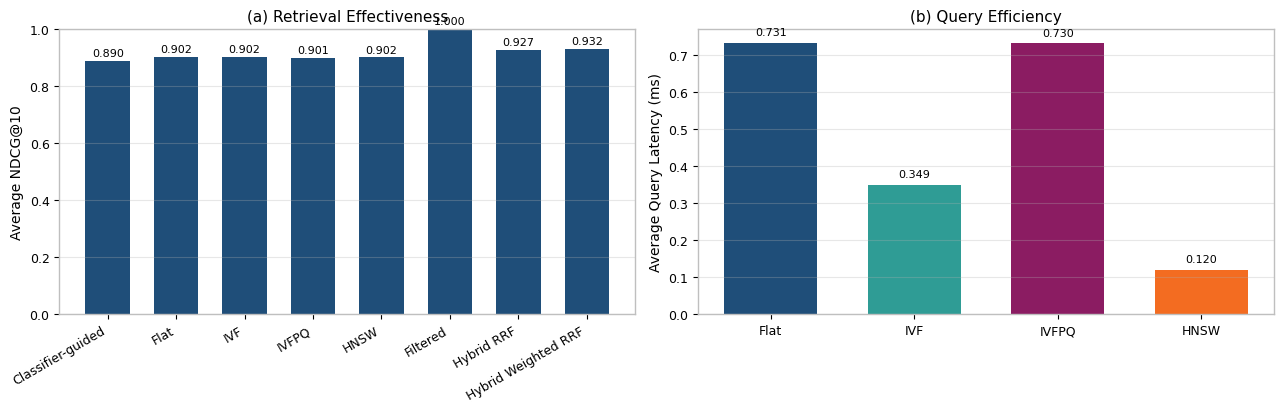

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Input files
# -----------------------------
result_folder = "E:\\Experiments\\Similarity Serach\\All-Results-Excel\\"

EXCEL_FILES = {
    "Classifier-guided": result_folder + "soft_filtering_results.xlsx",
    "Flat": result_folder + "faiss_flatl2_results.xlsx",
    "IVF": result_folder + "faiss_ivf_results.xlsx",
    "IVFPQ": result_folder + "faiss_ivfpq_results.xlsx",
    "HNSW": result_folder + "faiss_hnsw_results.xlsx",
    "Filtered": result_folder + "filtered_static_threshold_results.xlsx",
}


# hybrid files saved as CSV
CSV_FILES = {
    "Hybrid RRF": result_folder + "hybrid_rrf_run.csv",
    "Hybrid Weighted RRF": result_folder + "hybrid_weighted_rrf_run.csv",
}

LATENCY_FILE = result_folder + "index_latency_results.xlsx"

# -----------------------------
# Settings
# -----------------------------
TARGET_METRIC = "cosine"
TARGET_K = 10

bar_color_perf = "#1f4e79"
latency_colors = ["#1f4e79", "#2f9c95", "#8b1c62", "#f36c21"]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#BFBFBF",
    "axes.linewidth": 1.0,
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

# -----------------------------
# Metric helpers for hybrid CSV runs
# -----------------------------
def dcg_at_k(rels, k):
    rels = np.asarray(rels[:k])
    if len(rels) == 0:
        return 0.0
    denom = np.log2(np.arange(2, len(rels) + 2))
    return float(np.sum(rels / denom))

def ndcg_at_k(rels, k):
    dcg = dcg_at_k(rels, k)
    ideal = sorted(rels, reverse=True)
    idcg = dcg_at_k(ideal, k)
    return 0.0 if idcg == 0 else dcg / idcg

def compute_avg_ndcg_from_run_csv(csv_path, k=10):
    df = pd.read_csv(csv_path)

    # expected columns:
    # embedding, metric, method, query_id, query_label, doc_id, doc_label, rank, ...
    if "metric" in df.columns:
        df = df[df["metric"].astype(str).str.lower() == TARGET_METRIC].copy()

    ndcgs = []

    for _, g in df.groupby(["embedding", "query_id"]):
        g = g.sort_values("rank")
        rels = (g["doc_label"].to_numpy() == g["query_label"].iloc[0]).astype(np.int32)
        ndcgs.append(ndcg_at_k(rels, k))

    return float(np.mean(ndcgs))

# -----------------------------
# Load effectiveness results
# -----------------------------
perf_rows = []

# 6 single methods from Excel Summary
for method_name, file_path in EXCEL_FILES.items():
    df = pd.read_excel(file_path, sheet_name="Summary", engine="openpyxl")
    df = df[df["metric"].astype(str).str.lower() == TARGET_METRIC].copy()
    df["K"] = df["K"].astype(int)
    df = df[df["K"] == TARGET_K]

    perf_rows.append({
        "method": method_name,
        "avg_ndcg@10": df["ndcg@K"].mean()
    })

# 2 hybrid methods from CSV runs
for method_name, file_path in CSV_FILES.items():
    avg_ndcg = compute_avg_ndcg_from_run_csv(file_path, k=TARGET_K)
    perf_rows.append({
        "method": method_name,
        "avg_ndcg@10": avg_ndcg
    })

perf_df = pd.DataFrame(perf_rows)

method_order = [
    "Classifier-guided",
    "Flat",
    "IVF",
    "IVFPQ",
    "HNSW",
    "Filtered",
    "Hybrid RRF",
    "Hybrid Weighted RRF"
]
perf_df["method"] = pd.Categorical(perf_df["method"], categories=method_order, ordered=True)
perf_df = perf_df.sort_values("method")

# -----------------------------
# Load latency results
# -----------------------------
lat_df = pd.read_excel(LATENCY_FILE, sheet_name="LatencyResults", engine="openpyxl")

lat_summary = (
    lat_df.groupby("method", as_index=False)["avg_query_time_ms"]
    .mean()
)

latency_order = ["Flat", "IVF", "IVFPQ", "HNSW"]
lat_summary["method"] = pd.Categorical(lat_summary["method"], categories=latency_order, ordered=True)
lat_summary = lat_summary.sort_values("method")

# -----------------------------
# Plot combined figure
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# ---- Panel (a): Effectiveness ----
ax = axes[0]
x = np.arange(len(perf_df))

bars = ax.bar(
    x,
    perf_df["avg_ndcg@10"].values,
    width=0.65,
    color=bar_color_perf
)

ax.set_title("(a) Retrieval Effectiveness")
ax.set_ylabel("Average NDCG@10")
ax.set_xticks(x)
ax.set_xticklabels(perf_df["method"], rotation=30, ha="right")
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=0.3)

for b in bars:
    h = b.get_height()
    ax.text(
        b.get_x() + b.get_width() / 2,
        h + 0.01,
        f"{h:.3f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

# ---- Panel (b): Efficiency ----
ax = axes[1]
x2 = np.arange(len(lat_summary))

bars2 = ax.bar(
    x2,
    lat_summary["avg_query_time_ms"].values,
    width=0.65,
    color=latency_colors[:len(lat_summary)]
)

ax.set_title("(b) Query Efficiency")
ax.set_ylabel("Average Query Latency (ms)")
ax.set_xticks(x2)
ax.set_xticklabels(lat_summary["method"], rotation=0)
ax.grid(axis="y", alpha=0.3)

offset = max(lat_summary["avg_query_time_ms"]) * 0.02 if len(lat_summary) else 0.01
for b in bars2:
    h = b.get_height()
    ax.text(
        b.get_x() + b.get_width() / 2,
        h + offset,
        f"{h:.3f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

3 dimensions

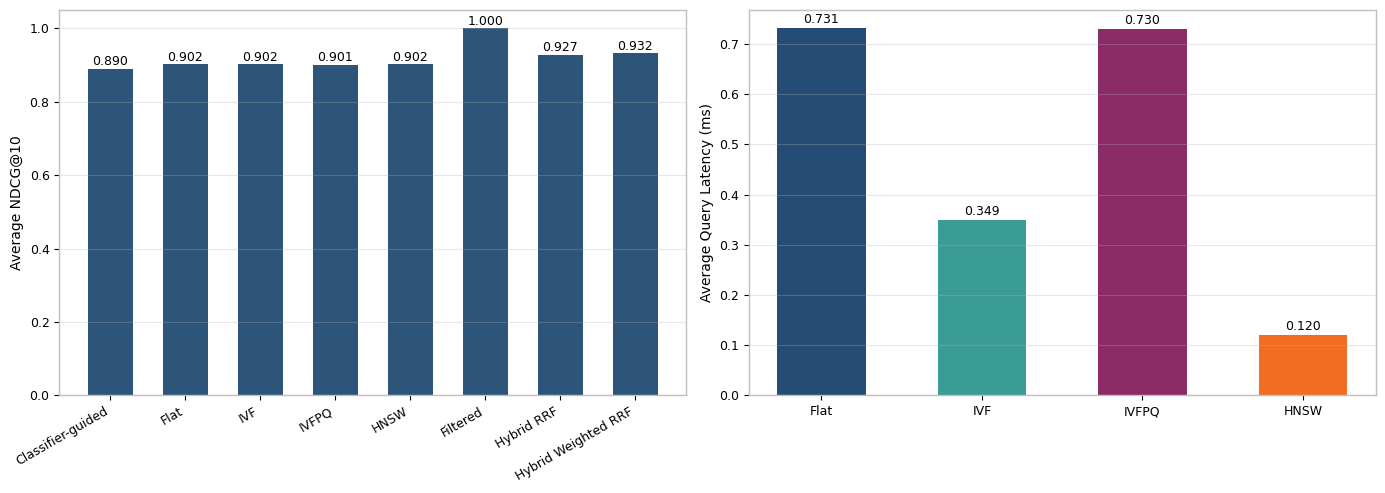

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import FancyBboxPatch

# =========================================================
# Files
# =========================================================
result_folder = "E:\\Experiments\\Similarity Serach\\All-Results-Excel\\"

# SUMMARY_FILES = {
#     "Classifier-guided": result_folder + "soft_filtering_results.xlsx",
#     "Flat": result_folder + "faiss_flatl2_results.xlsx",
#     "IVF": result_folder + "faiss_ivf_results.xlsx",
#     "IVFPQ": result_folder + "faiss_ivfpq_results.xlsx",
#     "HNSW": result_folder + "faiss_hnsw_results.xlsx",
#     "Filtered": result_folder + "filtered_static_threshold_results.xlsx",
#     "Hybrid RRF": result_folder + "hybrid_rrf_summary.xlsx",
#     "Hybrid Weighted RRF": result_folder + "hybrid_weighted_rrf_summary.xlsx",
# }

# LATENCY_FILE = result_folder + "index_latency_results.xlsx"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ================================
# Files
# ================================
FILES = {
    "Classifier-guided": result_folder + "soft_filtering_results.xlsx",
    "Flat": result_folder + "faiss_flatl2_results.xlsx",
    "IVF": result_folder + "faiss_ivf_results.xlsx",
    "IVFPQ": result_folder + "faiss_ivfpq_results.xlsx",
    "HNSW": result_folder + "faiss_hnsw_results.xlsx",
    "Filtered": result_folder + "filtered_static_threshold_results.xlsx",
    "Hybrid RRF": result_folder + "hybrid_rrf_summary.xlsx",
    "Hybrid Weighted RRF": result_folder + "hybrid_weighted_rrf_summary.xlsx",
}

LAT_FILE = result_folder + "index_latency_results.xlsx"

TARGET_K = 10
TARGET_METRIC = "cosine"

# ================================
# Read effectiveness results
# ================================
rows = []

for method, file in FILES.items():

    df = pd.read_excel(file, sheet_name="Summary")

    df = df[df["metric"] == TARGET_METRIC]
    df = df[df["K"] == TARGET_K]

    rows.append({
        "method": method,
        "ndcg": df["ndcg@K"].mean()
    })

perf = pd.DataFrame(rows)

method_order = [
    "Classifier-guided",
    "Flat",
    "IVF",
    "IVFPQ",
    "HNSW",
    "Filtered",
    "Hybrid RRF",
    "Hybrid Weighted RRF"
]

perf["method"] = pd.Categorical(perf["method"], method_order)
perf = perf.sort_values("method")

# ================================
# Read latency results
# ================================
lat = pd.read_excel(LAT_FILE)

lat = lat.groupby("method")["avg_query_time_ms"].mean().reset_index()

lat = lat.set_index("method").loc[
    ["Flat","IVF","IVFPQ","HNSW"]
].reset_index()

# ================================
# Plot
# ================================
fig, axes = plt.subplots(1,2,figsize=(14,5))

# ------------------------
# (a) Retrieval
# ------------------------
ax = axes[0]

x = np.arange(len(perf))

bars = ax.bar(
    x,
    perf["ndcg"],
    color="#2d5579",
    width=0.6
)

# ax.set_title("(a) Retrieval Effectiveness",fontsize=13)
ax.set_ylabel("Average NDCG@10")

ax.set_xticks(x)
ax.set_xticklabels(perf["method"],rotation=30,ha="right")

ax.set_ylim(0,1.05)

ax.grid(axis="y",alpha=0.3)

for i,v in enumerate(perf["ndcg"]):
    ax.text(i,v+0.01,f"{v:.3f}",ha="center",fontsize=9)

# ------------------------
# (b) Latency
# ------------------------
ax = axes[1]

x = np.arange(len(lat))

colors = [
    "#244c74",
    "#3b9c95",
    "#8b2c66",
    "#f26c21"
]

bars = ax.bar(
    x,
    lat["avg_query_time_ms"],
    color=colors,
    width=0.55
)

# ax.set_title("(b) Query Efficiency",fontsize=13)
ax.set_ylabel("Average Query Latency (ms)")

ax.set_xticks(x)
ax.set_xticklabels(lat["method"])

ax.grid(axis="y",alpha=0.3)

for i,v in enumerate(lat["avg_query_time_ms"]):
    ax.text(i,v+0.01,f"{v:.3f}",ha="center",fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
FIG_NAME = "Retrieval_Effectiveness_Query_Efficiency.png"

fig.savefig(
    FIG_NAME,
    dpi=600,       
    bbox_inches="tight"
)

print("Figure saved as:", FIG_NAME)

✅ Figure saved as: Retrieval_Effectiveness_Query_Efficiency.png


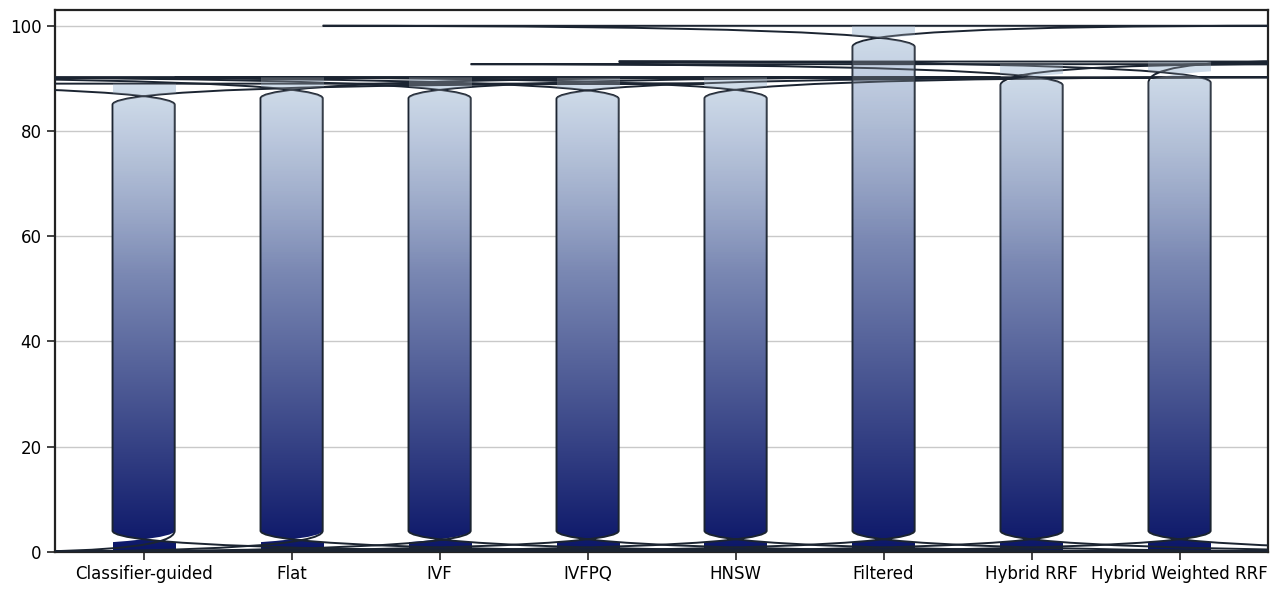

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import FancyBboxPatch

# =========================================================
# Files
# =========================================================
SUMMARY_FILES = {
    "Classifier-guided": "soft_filtering_results.xlsx",
    "Flat": "faiss_flatl2_results.xlsx",
    "IVF": "faiss_ivf_results.xlsx",
    "IVFPQ": "faiss_ivfpq_results.xlsx",
    "HNSW": "faiss_hnsw_results.xlsx",
    "Filtered": "filtered_static_threshold_results.xlsx",
    "Hybrid RRF": "hybrid_rrf_summary.xlsx",
    "Hybrid Weighted RRF": "hybrid_weighted_rrf_summary.xlsx",
}

LATENCY_FILE = "index_latency_results.xlsx"

TARGET_METRIC = "cosine"
TARGET_K = 10

# =========================================================
# Read retrieval effectiveness from original summary files
# =========================================================
perf_rows = []

for method_name, file_path in SUMMARY_FILES.items():
    df = pd.read_excel(file_path, sheet_name="Summary", engine="openpyxl")
    df = df[df["metric"].astype(str).str.lower() == TARGET_METRIC].copy()
    df["K"] = df["K"].astype(int)
    df = df[df["K"] == TARGET_K]

    perf_rows.append({
        "method": method_name,
        "avg_ndcg@10": df["ndcg@K"].mean()
    })

perf_df = pd.DataFrame(perf_rows)

method_order = [
    "Classifier-guided",
    "Flat",
    "IVF",
    "IVFPQ",
    "HNSW",
    "Filtered",
    "Hybrid RRF",
    "Hybrid Weighted RRF"
]
perf_df["method"] = pd.Categorical(perf_df["method"], categories=method_order, ordered=True)
perf_df = perf_df.sort_values("method").reset_index(drop=True)

# =========================================================
# Read latency results from original file
# =========================================================
lat_df = pd.read_excel(LATENCY_FILE, sheet_name="LatencyResults", engine="openpyxl")

lat_summary = (
    lat_df.groupby("method", as_index=False)["avg_query_time_ms"]
    .mean()
)

latency_order = ["Flat", "IVF", "IVFPQ", "HNSW"]
lat_summary["method"] = pd.Categorical(lat_summary["method"], categories=latency_order, ordered=True)
lat_summary = lat_summary.sort_values("method").reset_index(drop=True)

# =========================================================
# Helper: rounded gradient bar
# =========================================================
def rounded_gradient_bar(ax, x_center, height, width=0.56, bottom=0.0,
                         edgecolor="#263241", lw=1.4,
                         dark="#18267f", light="#c7d7e7"):
    """
    Draw a rounded bar with a soft vertical gradient.
    """
    left = x_center - width / 2
    bar_h = height - bottom

    # rounded patch border
    patch = FancyBboxPatch(
        (left, bottom),
        width,
        bar_h,
        boxstyle="round,pad=0,rounding_size=0.18",
        linewidth=lw,
        edgecolor=edgecolor,
        facecolor="none",
        zorder=4
    )
    ax.add_patch(patch)

    # gradient image
    n = 256
    grad = np.linspace(0, 1, n).reshape(n, 1)
    cmap = mpl.colors.LinearSegmentedColormap.from_list(
        "softgrad", [dark, light]
    )

    im = ax.imshow(
        grad,
        extent=[left, left + width, bottom, height],
        origin="lower",
        aspect="auto",
        cmap=cmap,
        interpolation="bicubic",
        zorder=3
    )
    im.set_clip_path(patch)

# =========================================================
# Figure
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5.3))
fig.patch.set_facecolor("white")

# -------------------------
# (a) Retrieval Effectiveness
# -------------------------
ax = axes[0]
x = np.arange(len(perf_df))

for xi, val in zip(x, perf_df["avg_ndcg@10"].values):
    rounded_gradient_bar(
        ax,
        x_center=xi,
        height=val,
        width=0.56,
        edgecolor="#263241",
        dark="#18267f",
        light="#c7d7e7"
    )
    ax.text(
        xi, val + 0.015, f"{val:.3f}",
        ha="center", va="bottom", fontsize=9
    )

ax.set_title("(a) Retrieval Effectiveness", fontsize=13, fontweight="bold")
ax.set_ylabel("Average NDCG@10", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(perf_df["method"], rotation=28, ha="right", fontsize=9)
ax.set_ylim(0, 1.03)
ax.set_yticks(np.linspace(0, 1.0, 6))
ax.grid(axis="y", color="#bfbfbf", linewidth=0.9, alpha=0.8)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_linewidth(1.1)
    spine.set_color("#333333")

ax.tick_params(axis="both", length=5, width=1.1, color="#333333")

# -------------------------
# (b) Query Efficiency
# -------------------------
ax = axes[1]
x2 = np.arange(len(lat_summary))

lat_colors = [
    ("#1b3b63", "#b9cde3"),   # Flat
    ("#a9660d", "#f6cf92"),   # IVF
    ("#5c6f2f", "#dbe7b1"),   # IVFPQ
    ("#2e7ea4", "#bfe6fb"),   # HNSW
]

for xi, val, (dark, light) in zip(x2, lat_summary["avg_query_time_ms"].values, lat_colors):
    rounded_gradient_bar(
        ax,
        x_center=xi,
        height=val,
        width=0.50,
        edgecolor="#263241",
        dark=dark,
        light=light
    )
    ax.text(
        xi, val + 0.015, f"{val:.3f}",
        ha="center", va="bottom", fontsize=9
    )

ax.set_title("(b) Query Efficiency", fontsize=13, fontweight="bold")
ax.set_ylabel("Average Query Latency (ms)", fontsize=11)
ax.set_xticks(x2)
ax.set_xticklabels(lat_summary["method"], fontsize=10)
ax.set_ylim(0, max(lat_summary["avg_query_time_ms"]) * 1.18)
ax.grid(axis="y", color="#bfbfbf", linewidth=0.9, alpha=0.8)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_linewidth(1.1)
    spine.set_color("#333333")

ax.tick_params(axis="both", length=5, width=1.1, color="#333333")

plt.subplots_adjust(wspace=0.18, left=0.07, right=0.98, top=0.90, bottom=0.28)
plt.show()

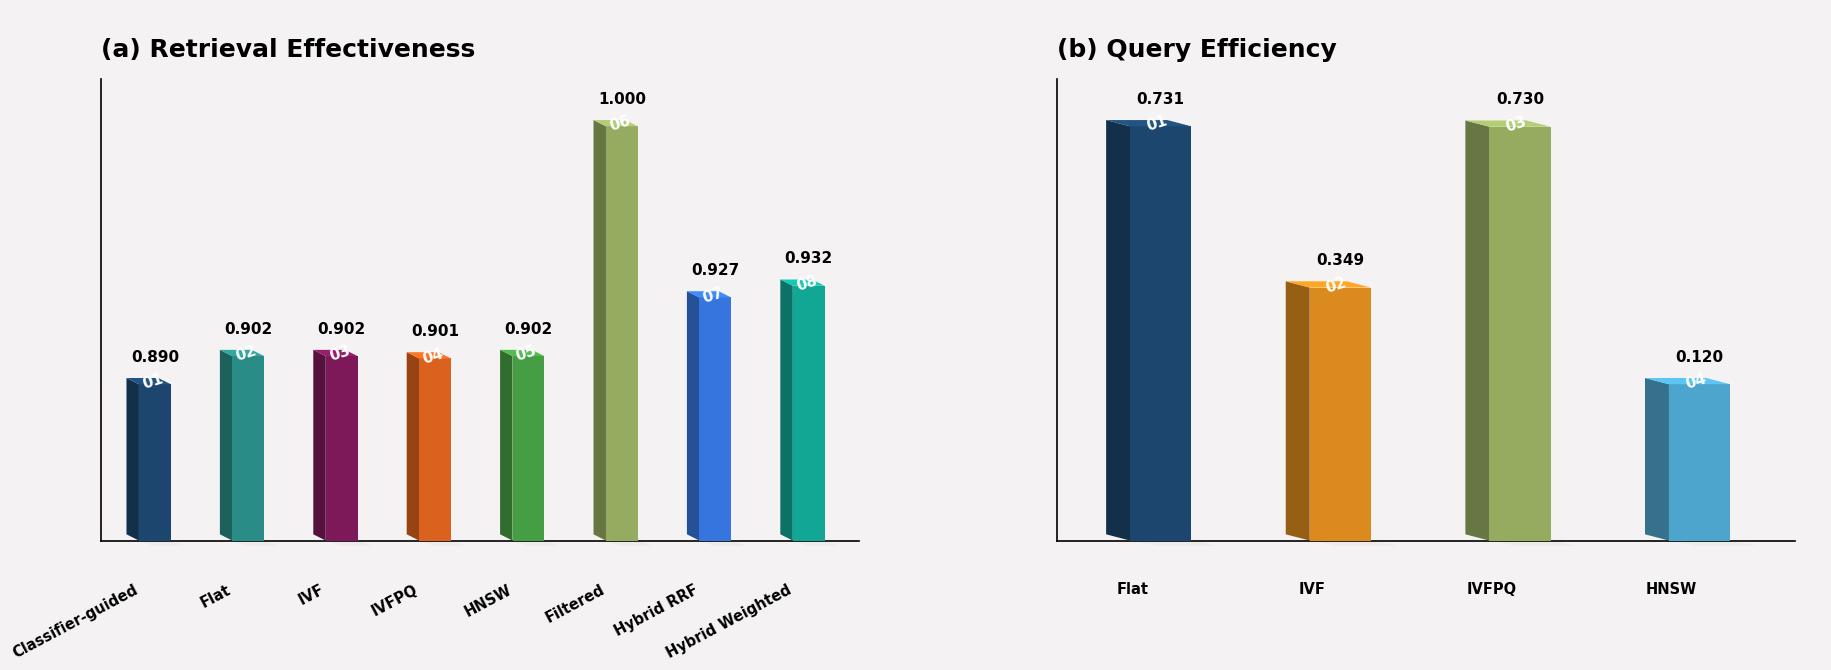

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import matplotlib.colors as mcolors
import numpy as np

# =========================
# Data
# =========================
methods_eff = [
    "Classifier-guided", "Flat", "IVF", "IVFPQ",
    "HNSW", "Filtered", "Hybrid RRF", "Hybrid Weighted"
]
values_eff = [0.890, 0.902, 0.902, 0.901, 0.902, 1.000, 0.927, 0.932]

methods_time = ["Flat", "IVF", "IVFPQ", "HNSW"]
values_time = [0.731, 0.349, 0.730, 0.120]

# =========================
# Helpers
# =========================
def adjust_color(color, factor=1.0):
    rgb = np.array(mcolors.to_rgb(color))
    return np.clip(rgb * factor, 0, 1)

def draw_shadow(ax, x, y, w, dx, dy, alpha=0.22):
    shadow = np.array([
        [x, y],
        [x + w, y],
        [x + w + dx * 1.15, y - dy * 0.85],
        [x + dx * 1.15, y - dy * 0.85]
    ])
    ax.add_patch(Polygon(shadow, closed=True, facecolor="#d9d9d9", edgecolor="none", alpha=alpha, zorder=1))

def draw_3d_column(ax, x, y, w, h, dx, dy, color, top_label):
    front = np.array([
        [x, y],
        [x + w, y],
        [x + w, y + h],
        [x, y + h]
    ])

    side = np.array([
        [x, y],
        [x - dx, y + dy],
        [x - dx, y + h + dy],
        [x, y + h]
    ])

    top = np.array([
        [x, y + h],
        [x + w, y + h],
        [x + w - dx, y + h + dy],
        [x - dx, y + h + dy]
    ])

    draw_shadow(ax, x, y, w, dx, dy, alpha=0.26)

    ax.add_patch(Polygon(side, closed=True, facecolor=adjust_color(color, 0.62), edgecolor="none", zorder=3))
    ax.add_patch(Polygon(front, closed=True, facecolor=adjust_color(color, 0.90), edgecolor="none", zorder=4))
    ax.add_patch(Polygon(top, closed=True, facecolor=adjust_color(color, 1.08), edgecolor="none", zorder=5))

    # top label
    ax.text(
        x + w * 0.52 - dx * 0.22,
        y + h + dy * 0.54,
        top_label,
        ha="center",
        va="center",
        fontsize=11,
        rotation=18,
        color="white",
        fontweight="bold",
        zorder=6
    )

def draw_axes(ax, x_min, x_max, y0, y_max):
    # x axis
    ax.plot([x_min, x_max], [y0, y0], color="black", lw=1.2, zorder=2)
    # y axis
    ax.plot([x_min, x_min], [y0, y_max], color="black", lw=1.2, zorder=2)

def draw_infographic_panel(ax, methods, values, colors, title, value_fmt="ndcg", rotate_xticks=False):
    ax.set_facecolor("#f4f2f2")

    step = 1.35
    x_positions = np.arange(len(methods)) * step + 1.1

    base_y = 1.35
    bar_w = 0.46
    dx = 0.18
    dy = 0.08

    min_h = 2.0
    max_h = 5.3
    vmin = min(values)
    vmax = max(values)
    heights = [min_h + (v - vmin) / (vmax - vmin + 1e-9) * (max_h - min_h) for v in values]

    x_axis_min = x_positions[0] - 0.55
    x_axis_max = x_positions[-1] + 0.95
    y_axis_max = 7.25

    draw_axes(ax, x_axis_min, x_axis_max, base_y, y_axis_max)

    for i, (x, h, v, c, m) in enumerate(zip(x_positions, heights, values, colors, methods), start=1):
        if value_fmt == "ms":
            value_label = f"{v:.3f}"
        else:
            value_label = f"{v:.3f}"

        top_label = f"{i:02d}"

        draw_3d_column(
            ax=ax,
            x=x,
            y=base_y,
            w=bar_w,
            h=h,
            dx=dx,
            dy=dy,
            color=c,
            top_label=top_label
        )

        ax.text(
            x + bar_w / 2,
            base_y + h + dy + 0.18,
            value_label,
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            color="black",
            zorder=7
        )

        rotation = 28 if rotate_xticks else 0
        ha = "right" if rotate_xticks else "center"
        ax.text(
            x + 0.02,
            0.83,
            m,
            ha=ha,
            va="top",
            rotation=rotation,
            fontsize=10.5,
            fontweight="bold",
            color="black",
            zorder=7
        )

    ax.text(
        x_axis_min,
        7.55,
        title,
        fontsize=18,
        fontweight="bold",
        color="black"
    )

    ax.set_xlim(x_axis_min - 0.1, x_axis_max + 0.2)
    ax.set_ylim(0, 8.15)
    ax.axis("off")

# =========================
# Colors
# =========================
colors_eff = [
    "#1f4e79", "#2f9c95", "#8b1c62", "#f36c21",
    "#4daf4a", "#a6bf6b", "#3b82f6", "#14b8a6"
]
colors_time = ["#1f4e79", "#f39a20", "#a6bf6b", "#55b6e3"]

# =========================
# Figure
# =========================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("#f4f2f2")

draw_infographic_panel(
    axes[0],
    methods_eff,
    values_eff,
    colors_eff,
    title="(a) Retrieval Effectiveness",
    value_fmt="ndcg",
    rotate_xticks=True
)

draw_infographic_panel(
    axes[1],
    methods_time,
    values_time,
    colors_time,
    title="(b) Query Efficiency",
    value_fmt="ms",
    rotate_xticks=False
)

plt.subplots_adjust(wspace=0.22, left=0.03, right=0.99, top=0.96, bottom=0.05)
plt.show()

radar chart

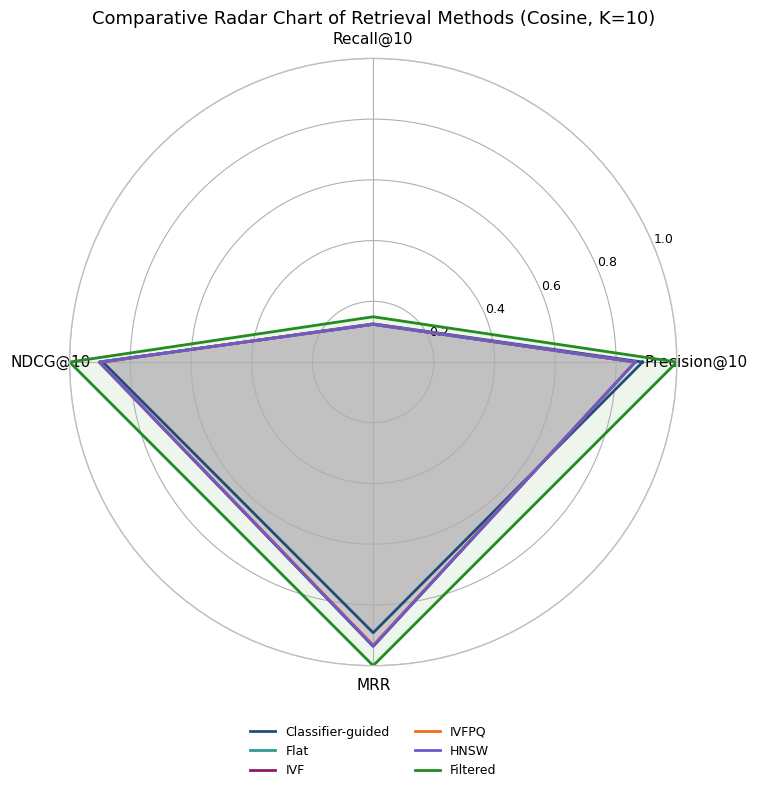

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Input files
# -----------------------------
result_folder = "E:\\Experiments\\Similarity Serach\\All-Results-Excel\\"

EXCEL_FILES = {
    "Classifier-guided": result_folder + "soft_filtering_results.xlsx",
    "Flat": result_folder + "faiss_flatl2_results.xlsx",
    "IVF": result_folder + "faiss_ivf_results.xlsx",
    "IVFPQ": result_folder + "faiss_ivfpq_results.xlsx",
    "HNSW": result_folder + "faiss_hnsw_results.xlsx",
    "Filtered": result_folder + "filtered_static_threshold_results.xlsx",
}


# hybrid files saved as CSV
CSV_FILES = {
    "Hybrid RRF": result_folder + "hybrid_rrf_run.csv",
    "Hybrid Weighted RRF": result_folder + "hybrid_weighted_rrf_run.csv",
}

LATENCY_FILE = result_folder + "index_latency_results.xlsx"

TARGET_METRIC = "cosine"
TARGET_K = 10

# -----------------------------
# Load and aggregate results
# -----------------------------
rows = []

for method_name, file_path in EXCEL_FILES.items():
    df = pd.read_excel(file_path, sheet_name="Summary", engine="openpyxl")
    df = df[df["metric"].astype(str).str.lower() == TARGET_METRIC].copy()
    df["K"] = df["K"].astype(int)
    df = df[df["K"] == TARGET_K]

    rows.append({
        "method": method_name,
        "Precision@10": df["precision@K"].mean(),
        "Recall@10": df["recall@K"].mean(),
        "NDCG@10": df["ndcg@K"].mean(),
        "MRR": df["mrr@K"].mean(),
    })

radar_df = pd.DataFrame(rows)

# -----------------------------
# Radar chart
# -----------------------------
categories = ["Precision@10", "Recall@10", "NDCG@10", "MRR"]
N = len(categories)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# colors
colors = [
    "#1f4e79", "#2f9c95", "#8b1c62", "#f36c21",
    "#6a5acd", "#228b22", "#b22222", "#696969"
]

for i, row in radar_df.iterrows():
    values = [row[c] for c in categories]
    values += values[:1]

    ax.plot(angles, values, linewidth=2, label=row["method"], color=colors[i % len(colors)])
    ax.fill(angles, values, alpha=0.08, color=colors[i % len(colors)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)

ax.set_ylim(0, 1.0)
ax.set_yticks(np.linspace(0.2, 1.0, 5))
ax.set_yticklabels([f"{x:.1f}" for x in np.linspace(0.2, 1.0, 5)], fontsize=9)

ax.set_title("Comparative Radar Chart of Retrieval Methods (Cosine, K=10)", pad=25, fontsize=13)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.show()